# Feature validation — the 11 candidate metadata features, measured

**What this is.** `reports/wf_eda_fe_report.md` §4 recommended a punch list of engineered
metadata features (`citation_velocity`, per-use-case percentile ranks, `has_venue`,
`author_count`, …). That was a *recommendation from EDA* — descriptive reads of means and
missing-value rates. **Nothing had measured whether the engineered versions actually
separate the labels.** This notebook does that, for all 11 at once, so the punch list can
be cut down to the ones that earn their place.

**What it is not:** it does not build the Week-3 feature matrix. It's a viability check in
the same mould as `terms_overlap.ipynb` / `venue_quality.ipynb` — read-only, nothing
written back to `data/processed/`.

## The 11 candidates

| Feature | Proposed definition |
|---|---|
| `citation_velocity` | `citation_count / paper_age` — de-confound citations from age |
| `has_venue` | venue recorded, after cleaning out arXiv and dirty long strings |
| `venue_is_arxiv_only` | paper exists only as a preprint |
| `author_count` | comma-separated count of authors |
| `per_use_case_percentile_citation_velocity` | rank within own use case |
| `per_use_case_percentile_author_count` | rank within own use case |
| `use_case_positive_terms` / `use_case_negative_terms` | regex term lists from the search brief |
| `term_overlap_positive` / `term_overlap_negative` | how many of those terms the paper hits |
| `is_english` | language is English |

**Two of these are already settled and are not re-litigated here.** `terms_overlap.ipynb`
and `terms_overlap_spacy.ipynb` already built the term-list regex features and measured
them: full-population ROC-AUC **0.70–0.80 on `cement_binders`/`carbon_capture`/`ner`**
(Mann-Whitney p < 0.0001), **chance on the other three** (0.46–0.56, none significant).
That verdict stands and is carried into §10's summary unchanged; this notebook spends its
effort on the 7 metadata candidates nobody has measured yet.

## Methodology, and which critic is speaking

- **§1–§6 report full-population ROC-AUC**: a single feature ranked against the labels,
  with no model fitted, so there's nothing to overfit and no folds are needed. Same
  convention (and the same phrase) as `terms_overlap.ipynb`. It is a **measurement**.
- **§9 fits models, so it is cross-validated**: `StratifiedGroupKFold(5)` on the dev pool,
  stratified on use_case+label, grouped by first author, `tech_forecasting` held out
  entirely — the fold design from `notebooks/modelling/wf_fold_pca_test.ipynb`. Every
  number is an **out-of-fold** prediction, and the per-use-case percentiles are fitted on
  the training fold only (a percentile computed over all rows peeks at the test fold).
- Anything labelled **judgement call** is my reading, not a computed result.

In [1]:
import re
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

DATA_PATH = "../../data/processed/papers_combined.parquet"

# Exports are dated 2026-08 (`exported_at`), so "now" is mid-2026. Hard-coded rather than
# datetime.now() so re-running this notebook next year doesn't silently change the numbers.
REF_YEAR = 2026.6
HOLDOUT_USE_CASE = "tech_forecasting"   # same holdout as wf_fold_pca_test.ipynb
N_SPLITS, RANDOM_STATE = 5, 42

# Same visual convention as the other notebooks in this repo.
ACCENT = "#2a78d6"
MUTED = "#96948c"
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e", "ytick.color": "#52514e", "text.color": "#0b0b0b",
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.6,
    "axes.axisbelow": True, "font.size": 10,
})
pd.set_option("display.width", 200)

df = pd.read_parquet(DATA_PATH)
print(f"Loaded {df.shape[0]} rows x {df.shape[1]} columns")
print(f"use cases: {sorted(df['use_case_key'].unique())}")

Loaded 2873 rows x 50 columns
use cases: ['carbon_capture', 'cement_binders', 'ner', 'soil_microbiome', 'solar_leo', 'tech_forecasting']


## 1. Building the 11 features

This is the reference implementation of each proposed definition — if any of these
survive, this is the code to lift into the pipeline.

Two conventions from `CLAUDE.md` are load-bearing here:

- **NULL ≠ 0.** `citation_count` null means "never looked up"; 0 means "looked up, found
  nothing". `author_count` is `NA` for an unparseable author string, never 0 — a real
  paper never has zero authors. Nothing is `fillna(0)`'d.
- Missingness gets its **own indicator column** (`citation_count_missing`) rather than
  being imputed away. §5 shows this turns out to matter far more than expected.

In [2]:
PREPRINT_RE = re.compile(
    r"arxiv|biorxiv|chemrxiv|medrxiv|ssrn|preprints?\.org|research\s*square|zenodo|osf\b", re.I)


def parse_author_count(s):
    "Comma-split. NA (not 0) when the author string is missing or empty."
    if pd.isna(s) or not s.strip():
        return pd.NA
    return len([a for a in s.split(",") if a.strip()])


f = df.copy()

# --- venue -------------------------------------------------------------------------
# Both NaN and empty string mean "not recorded" -> one missing state, not two.
f["venue_norm"] = f["venue"].fillna("").str.strip().replace("", pd.NA)
f["has_venue"] = f["venue_norm"].notna()
f["venue_is_preprint"] = f["venue_norm"].fillna("").str.contains(PREPRINT_RE)
# "Only ever a preprint" = arXiv found it AND there is no non-preprint venue for it.
f["venue_is_arxiv_only"] = f["from_arxiv"] & (~f["has_venue"] | f["venue_is_preprint"])

# --- citations ---------------------------------------------------------------------
# clip(lower=0.5) not (+1): 642 rows are dated 2026 and 1 is dated 2027, so age can be
# <= 0. Half a year is the smallest honest denominator rather than a magic +1.
f["paper_age"] = (REF_YEAR - f["year"]).clip(lower=0.5)
f["citation_velocity"] = f["citation_count"] / f["paper_age"]
f["citation_count_missing"] = f["citation_count"].isna()

# --- authors / language ------------------------------------------------------------
f["author_count"] = f["authors"].apply(parse_author_count).astype("Int64")
f["is_english"] = f["language"].eq("en")

# --- per-use-case percentile ranks --------------------------------------------------
# NOTE: computed over the whole dataset here, which is fine for the descriptive reads in
# §2-§8 (no model is fitted). §9 refits them per training fold.
for c in ["citation_velocity", "author_count"]:
    f[f"pct_{c}"] = f.groupby("use_case_key")[c].rank(pct=True)

CANDIDATES = ["citation_velocity", "pct_citation_velocity", "has_venue",
              "venue_is_arxiv_only", "venue_is_preprint", "author_count", "pct_author_count",
              "is_english", "citation_count_missing"]
print(f["citation_velocity"].describe().round(2).to_string())

count    2448.0
mean      13.18
std       34.02
min         0.0
25%         0.0
50%         1.1
75%       10.66
max      744.55


## 2. Coverage and degeneracy audit

Before asking whether a feature *separates the labels*, ask whether it **varies at all**.
A feature that is one value for 99% of rows cannot carry signal regardless of what any
AUC says.

In [3]:
audit = pd.DataFrame({
    "non_null_%": (f[CANDIDATES].notna().mean() * 100).round(1),
    "n_unique": [f[c].nunique(dropna=True) for c in CANDIDATES],
    "majority_value_%": [round(100 * f[c].value_counts(normalize=True, dropna=True).iloc[0], 1)
                         for c in CANDIDATES],
})
print(audit.to_string())
print()
print("language value counts:")
print(df["language"].value_counts(dropna=False).to_string())

                        non_null_%  n_unique  majority_value_%
citation_velocity             85.2       776              39.5
pct_citation_velocity         85.2      1022               9.4
has_venue                    100.0         2              72.9
venue_is_arxiv_only          100.0         2              96.7
venue_is_preprint            100.0         2              95.0
author_count                  97.6        37              16.4
pct_author_count              97.6       120               4.5
is_english                   100.0         2              99.0
citation_count_missing       100.0         2              85.7

language value counts:
language
en    2843
sv       9
fr       4
de       3
it       3
no       3
id       2
es       1
ru       1
da       1
tr       1
sl       1
nl       1


**Finding (hard numbers): `is_english` is dead on arrival.** 2,843 of 2,873 rows (**98.96%**)
are `en`. The remaining 30 rows are spread across **12** other languages — the largest
non-English group is 9 Swedish rows. A boolean that is `True` 99% of the time has almost
no variance to regress on, and 30 exceptions across 12 languages are too few to estimate
anything from.

`citation_velocity` at **85.2%** coverage is the other number to note: 410 rows have no
`citation_count`, and 15 more have no `year` to divide by. §5 shows *which* rows lack a
citation count, and why that is not random.

## 3. "Clean out arXiv and long strings" — does that job need doing?

The plan for `has_venue` was to null out arXiv and "long strings" before counting a venue
as present. `wf_data_enrich.ipynb` did find full citation strings sitting in the `venue`
field. The question is how many — because **length is only a safe filter if long venue
names are actually dirt**, and academic conferences have genuinely long names.

In [4]:
venues = f["venue_norm"].dropna()
long_venues = sorted(venues[venues.str.len() > 100].unique(), key=len, reverse=True)
REAL_LONG_RE = re.compile(
    r"proceedings|conference|workshop|symposium|congress|seminar|lecture notes|annual meeting", re.I)
real = [v for v in long_venues if REAL_LONG_RE.search(v)]
suspect = [v for v in long_venues if not REAL_LONG_RE.search(v)]

print(f"non-empty venues: {len(venues)} rows / {venues.nunique()} unique")
print(f"venue length percentiles: "
      f"{venues.str.len().quantile([.5, .9, .99]).astype(int).to_dict()}  max={venues.str.len().max()}")
print(f"\nunique venues > 100 chars: {len(long_venues)}")
print(f"  ...of which name a real conference/proceedings: {len(real)}")
print(f"  ...genuinely suspect: {len(suspect)}\n")
for v in suspect:
    print(f"  [{len(v)}] {v[:105]}")

non-empty venues: 2094 rows / 918 unique
venue length percentiles: {0.5: 26, 0.9: 66, 0.99: 116}  max=234

unique venues > 100 chars: 42
  ...of which name a real conference/proceedings: 40
  ...genuinely suspect: 2

  [201] pan, g., zhou, t., zhao, j., li, z., lin, y., ma, b., ... & wang, s. (2026). graph neural networks based 
  [163] enhancing drug repurposing accuracy through ai-orchestrated integration of knowledge graph reasoning, str


**Finding (hard numbers): the long-string cleanup would do more harm than good.** Of the
42 unique venue strings over 100 characters, **40 name real conferences or proceedings**
("proceedings of the 63rd annual meeting of the association for computational
linguistics…"). Exactly **2 are genuinely dirty** — one author list that swallowed a whole
citation, one paper title in the venue field.

So the true dirt is **2 strings out of 918 unique / 2,094 populated** — about **0.1% of
rows**. A length threshold aggressive enough to catch them deletes 40 legitimate
conference venues.

**Judgement call: drop this cleanup step.** Two bad rows do not justify a regex that
silently discards real venues, and the min-frequency threshold you need anyway for
frequency/target encoding (singleton venues fold into "other") already neutralises them.
YAGNI.

## 4. `venue_is_arxiv_only` — the definition doesn't hold up

The intent is "this paper only ever existed as a preprint". The available columns give
two different, non-equivalent ways to ask that, and they disagree.

In [5]:
n_arxiv = f["from_arxiv"].sum()
print(f"from_arxiv rows                              : {n_arxiv}")
print(f"  ...with no venue at all                    : {(f.from_arxiv & ~f.has_venue).sum()}")
print(f"  ...whose venue IS a preprint server        : {(f.from_arxiv & f.venue_is_preprint).sum()}")
print(f"  ...whose venue is a REAL journal           : "
      f"{(f.from_arxiv & f.has_venue & ~f.venue_is_preprint).sum()}   <- published, not preprint-only")
print(f"preprint venue but NOT from_arxiv            : "
      f"{(~f.from_arxiv & f.venue_is_preprint).sum()}   <- SSRN/bioRxiv/etc, missed by from_arxiv")
print(f"\n-> venue_is_arxiv_only as defined            : {f.venue_is_arxiv_only.sum()} rows "
      f"({100 * f.venue_is_arxiv_only.mean():.1f}%)")
print("\nCorrelation with the from_arxiv column it is derived from:")
print(f"  phi = {np.corrcoef(f.venue_is_arxiv_only.astype(int), f.from_arxiv.astype(int))[0, 1]:.3f}")

from_arxiv rows                              : 137
  ...with no venue at all                    : 0
  ...whose venue IS a preprint server        : 96
  ...whose venue is a REAL journal           : 41   <- published, not preprint-only
preprint venue but NOT from_arxiv            : 49   <- SSRN/bioRxiv/etc, missed by from_arxiv

-> venue_is_arxiv_only as defined            : 96 rows (3.3%)

Correlation with the from_arxiv column it is derived from:
  phi = 0.831


**Finding (hard numbers), including a flaw in the definition I just wrote.**

- **41 arXiv-sourced papers carry a real journal venue.** arXiv's metadata includes a
  `journal-ref` once a preprint is published, so `from_arxiv` on its own would mislabel
  those 41 published papers as preprint-only. The definition above correctly excludes them.
- **But 49 papers sit on SSRN / bioRxiv / ChemRxiv with `from_arxiv` unset** — and because
  the definition *requires* `from_arxiv`, it misses every one of them. It is not "is this
  a preprint", it is "is this an arXiv preprint", which is a narrower and less interesting
  question.
- Not one of the 137 arXiv rows has an empty venue, so the `~has_venue` half of the
  definition never fires. What is left is `from_arxiv AND venue is a preprint server` —
  96 rows, **φ = 0.831** with the `from_arxiv` column already in the parquet.

**The better definition is `venue_is_preprint` on its own** (145 rows, no `from_arxiv`
requirement) — so §6 measures that one too rather than only the flawed version. Both land
at chance.

## 5. The missingness confound — is a null a fact about the paper, or about the API?

`has_venue` and `citation_count_missing` are both "was this recorded?" features. That is
only a fact about the *paper* if recording is paper-dependent. Here it isn't.

In [6]:
src_cols = sorted(c for c in f.columns if c.startswith("from_"))
rows = []
for c in src_cols:
    single = f[f[c] & (f[src_cols].sum(axis=1) == 1)]     # rows found by exactly one source
    if len(single) < 20:
        continue
    rows.append({"source": c.replace("from_", ""), "n": len(single),
                 "citation_count NULL %": round(100 * single.citation_count.isna().mean(), 1),
                 "venue NULL %": round(100 * (~single.has_venue).mean(), 1)})
print("Single-source rows only, so nothing is double-counted:\n")
print(pd.DataFrame(rows).set_index("source").to_string())

Single-source rows only, so nothing is double-counted:

                    n  citation_count NULL %  venue NULL %
source                                                    
arxiv             135                  100.0           0.0
core               66                  100.0         100.0
crossref          977                    0.0          22.3
europe_pmc        404                    0.0         100.0
openalex          895                    0.0           8.5
pubmed            180                  100.0           0.0
seed               30                    0.0           3.3
semantic_scholar   33                    0.0           3.0


**Finding (hard numbers): missingness is a perfect proxy for which API found the paper.**
`citation_count` is null for **100.0%** of pubmed, arxiv and core rows and **0.0%** of
crossref, openalex, europe_pmc, semantic_scholar and seed rows. `venue` is null for
**100.0%** of europe_pmc and core rows and **0.0%** of arxiv and pubmed rows. These are
not noisy correlations — they are the APIs' response schemas showing through.

So `has_venue` and `citation_count_missing` do not measure the paper. They re-encode
`sources`, which is **already in the parquet** as `from_*` booleans. Whatever they predict,
they predict *because* different search backends were hit by different use cases' queries —
a property of the retrieval pipeline, not of whether a paper answers the research question.

**This is the main risk in the whole feature list**, and §6 shows it is not hypothetical.

## 6. Single-feature separation

Full-population ROC-AUC of each candidate against `triage_label` ∈ {positive, negative}.
No model is fitted. `year` and `relevance_score` are included as reference points — one
raw column that was never proposed as a feature, and the incumbent signal to beat.

In [7]:
lab = f[f["triage_label"].isin(["positive", "negative"])].copy()
lab["y"] = (lab["triage_label"] == "positive").astype(int)
print(f"labelled positive/negative rows: {len(lab)} of {len(f)}")

FEATS = ["citation_count", "citation_velocity", "pct_citation_velocity", "has_venue",
         "venue_is_arxiv_only", "venue_is_preprint", "author_count", "pct_author_count",
         "is_english", "citation_count_missing", "year", "relevance_score"]


def full_pop_auc(g, c):
    s = g[[c, "y"]].dropna()
    s[c] = s[c].astype(float)
    if s["y"].nunique() < 2 or s[c].nunique() < 2 or len(s) < 30:
        return np.nan
    return roc_auc_score(s["y"], s[c])


tbl = [{"use_case": k, "n": len(g), **{c: full_pop_auc(g, c) for c in FEATS}}
       for k, g in lab.groupby("use_case_key")]
tbl.append({"use_case": "** POOLED **", "n": len(lab), **{c: full_pop_auc(lab, c) for c in FEATS}})
auc_tbl = pd.DataFrame(tbl).set_index("use_case")
print()
print(auc_tbl.round(3).to_string())

labelled positive/negative rows: 1852 of 2873



                     n  citation_count  citation_velocity  pct_citation_velocity  has_venue  venue_is_arxiv_only  venue_is_preprint  author_count  pct_author_count  is_english  citation_count_missing   year  relevance_score
use_case                                                                                                                                                                                                                       
carbon_capture     297           0.471              0.466                  0.466      0.570                0.473              0.494         0.497             0.497       0.497                   0.474  0.428            0.607
cement_binders     262           0.483              0.468                  0.468      0.445                0.408              0.408         0.456             0.456       0.497                   0.238  0.362            0.903
ner                312           0.513              0.497                  0.497      0.513            

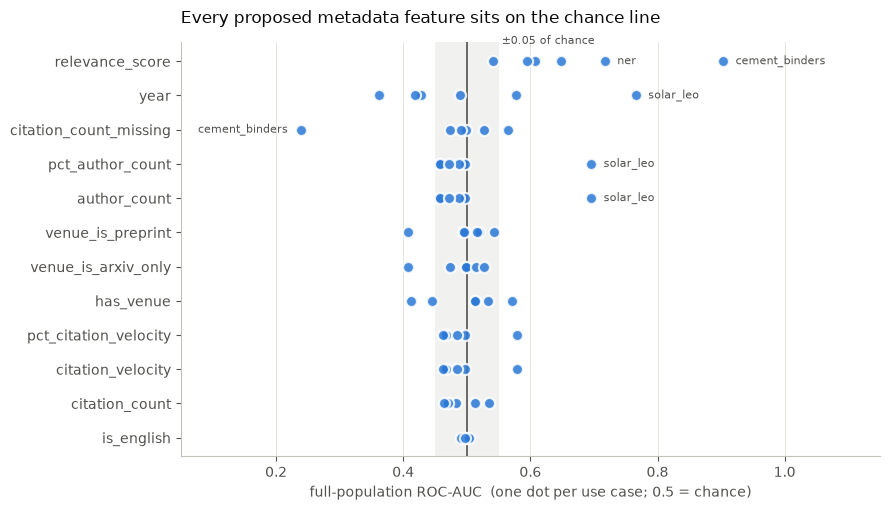

In [8]:
per_uc = auc_tbl.drop(index="** POOLED **")
order = (per_uc[FEATS] - 0.5).abs().max().sort_values().index

fig, ax = plt.subplots(figsize=(9, 5.2))
ax.axvline(0.5, color="#52514e", lw=1.2, zorder=3)
ax.axvspan(0.45, 0.55, color=MUTED, alpha=0.13, lw=0, zorder=0)
for i, feat in enumerate(order):
    v = per_uc[feat].dropna()
    ax.plot(v.to_numpy(), [i] * len(v), "o", ms=8, color=ACCENT,
            mec="white", mew=1.6, alpha=0.85, zorder=4)
    # Direct-label only the extremes, on the same row as the dot so there is no ambiguity
    # about which feature a label belongs to. A label on every point would be unreadable.
    for uc, val in v.items():
        if abs(val - 0.5) > 0.15:
            side = -1 if val < 0.5 else 1
            ax.annotate(uc, (val, i), textcoords="offset points",
                        xytext=(9 * side, 0), va="center",
                        ha="right" if side < 0 else "left", fontsize=8, color="#52514e")

ax.set_yticks(range(len(order)), order)
ax.set_xlabel("full-population ROC-AUC  (one dot per use case; 0.5 = chance)")
ax.set_title("Every proposed metadata feature sits on the chance line", loc="left", pad=14)
ax.text(0.555, len(order) - 0.4, "±0.05 of chance", color="#52514e", fontsize=8, va="center")
ax.set_xlim(0.05, 1.15)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

**Finding (hard numbers).**

- **`citation_velocity` does not fix `citation_count`.** The whole point of dividing by
  age was to remove the age confound §4.1 of the EDA report diagnosed. It moves AUC from
  0.471→0.466, 0.483→0.468, 0.513→0.497, 0.470→0.485, 0.535→0.578, 0.464→0.462. Five of
  six use cases stay **below** 0.5 (more citations → *less* likely positive), and only
  `solar_leo` clears chance by more than 0.05. Pooled: 0.479. The EDA's descriptive read
  ("mean velocity 15.9 vs 11.6") was driven by outliers — one paper here has 26,506
  citations — and a rank-based measure shows the effect is not there.
- **`is_english` is exactly chance everywhere** (0.491–0.503), as §2 predicted.
- **`has_venue` flips direction across use cases.** It is 0.570 on `carbon_capture`
  (venue present → positive) and 0.412 on `solar_leo` (venue present → negative). Both
  are individually significant (§7). A feature whose *sign* depends on the use case is a
  confound, not a signal — and pooled it washes out to 0.514.
- **Neither preprint feature carries anything.** `venue_is_arxiv_only` never gets further
  than 0.092 from chance, and the repaired `venue_is_preprint` (§4) does no better —
  measuring the better definition was worth doing, and it did not rescue the idea.
- **`author_count` is chance on 5 of 6** and 0.696 on `solar_leo`. But plain `year` scores
  **0.766** on that same corpus, and author count correlates +0.22 with year there:
  `solar_leo` is the only corpus spanning 52 years (1974–2026), and its negatives are
  simply older, smaller-team papers. Author count is a weaker proxy for recency.
- **The strongest metadata reading in the whole table belongs to a feature nobody
  proposed**: `citation_count_missing` scores **0.238** on `cement_binders` — further from
  chance (0.262) than anything except `relevance_score`. That is §5's confound made
  visible: on that corpus, "found via pubmed/arxiv/core" strongly predicts *negative*. It
  is real, it is exploitable, and it is about the search pipeline, not the paper.

## 7. Is any of it statistically significant?

AUC without a significance test invites reading noise as signal, especially at n≈300 per
use case. Mann-Whitney U, positives vs negatives, per use case (`*` = p < 0.05,
uncorrected — with 30 tests here, ~1–2 false positives are expected by chance alone).

In [9]:
sig_feats = ["citation_velocity", "author_count", "has_venue", "venue_is_arxiv_only", "is_english"]
out = []
for c in sig_feats:
    row = {"feature": c}
    for k, g in lab.groupby("use_case_key"):
        s = g[[c, "y"]].dropna()
        s[c] = s[c].astype(float)
        if s["y"].nunique() < 2 or s[c].nunique() < 2:
            row[k] = None
            continue
        p = mannwhitneyu(s.loc[s.y == 1, c], s.loc[s.y == 0, c]).pvalue
        row[k] = f"{p:.3f}{'*' if p < 0.05 else ''}"
    out.append(row)
print(pd.DataFrame(out).set_index("feature").to_string())

                    carbon_capture cement_binders    ner soil_microbiome solar_leo tech_forecasting
feature                                                                                            
citation_velocity            0.317          0.542  0.935           0.662    0.031*            0.321
author_count                 0.928          0.245  0.245           0.724    0.000*            0.429
has_venue                   0.012*         0.031*  0.628           0.242    0.002*            0.654
venue_is_arxiv_only         0.021*         0.000*  0.856           0.554     0.213            0.068
is_english                   0.316          0.467  0.205           0.554     0.756            0.413


**Finding (hard numbers).** `is_english` reaches significance nowhere. `citation_velocity`
reaches it once (`solar_leo`, p=0.031 — the recency corpus). `author_count` once
(`solar_leo`, p<0.001). The two venue features are the most "significant" of the lot —
`has_venue` on three use cases — which, given §5, is the confound being detected, and
`has_venue`'s significant results point in **opposite directions** (`carbon_capture`
p=0.012 positive-leaning, `solar_leo` p=0.002 negative-leaning).

## 8. Do the percentile features do anything?

The proposal was per-use-case percentile ranks of `citation_velocity` and `author_count`,
to stop a pooled model learning "solar_leo papers have more citations, and solar_leo is
mostly positive" as if it were relevance. The mean `citation_count` gap across use cases
is real and large, so the concern is well-founded. But percentile ranking is a **monotonic
transform within each use case** — and ROC-AUC only reads ranks.

In [10]:
print("mean citation_count per use case (the scale gap percentile ranking exists to remove):")
print(lab.groupby("use_case_key")["citation_count"].mean().round(1).to_string())
print()
print(f"{'use_case':20s} {'raw':>8s} {'percentile':>11s}   identical?")
for k, g in lab.groupby("use_case_key"):
    a, b = full_pop_auc(g, "citation_velocity"), full_pop_auc(g, "pct_citation_velocity")
    print(f"{k:20s} {a:8.4f} {b:11.4f}   {np.isclose(a, b)}")
a, b = full_pop_auc(lab, "citation_velocity"), full_pop_auc(lab, "pct_citation_velocity")
print(f"{'** POOLED **':20s} {a:8.4f} {b:11.4f}   {np.isclose(a, b)}   <- the only place it moves")

mean citation_count per use case (the scale gap percentile ranking exists to remove):
use_case_key
carbon_capture       46.3
cement_binders       78.5
ner                   7.7
soil_microbiome     139.3
solar_leo           240.1
tech_forecasting      3.4

use_case                  raw  percentile   identical?
carbon_capture         0.4660      0.4660   True
cement_binders         0.4679      0.4679   True
ner                    0.4971      0.4971   True
soil_microbiome        0.4849      0.4849   True
solar_leo              0.5784      0.5784   True
tech_forecasting       0.4619      0.4619   True
** POOLED **           0.4788      0.4908   False   <- the only place it moves


**Finding (hard numbers): the percentile features are mathematically inert within a use
case** — AUC identical to 4 decimal places on all six, because rank(pct) is monotonic and
AUC is rank-based. They change exactly one number in the table: the **pooled** read, 0.479
→ 0.491.

**This does not make them useless — it pins down precisely what they are.** They are a
*normalisation for pooling*, not a source of signal. Given the plan is to pool for the
ensemble build and then fine-tune per use case:

- **pooled stage** — keep them; that is the stage they were designed for, and they
  correctly neutralise the cross-use-case scale gap (mean citations 3.4 in
  `tech_forecasting` vs 240.1 in `solar_leo`).
- **per-use-case fine-tune** — drop them. They cannot change a single-use-case model's
  ranking, and carrying both raw and percentile there doubles the column count for nothing.

The caveat that matters more: normalising a feature that carries no signal (0.479 → 0.491,
both chance) yields a normalised feature that still carries no signal.

## 9. The decisive test — do these earn a place next to what we already have?

Everything above reads features one at a time. The real question is incremental: the
Week-3 model will already have the embedding and `relevance_score`. **Do the metadata
features add anything on top?**

The feature set tested is the **8 metadata columns** built in §1 — the 7 non-term
candidates from the proposal, plus `citation_count_missing`. The 4 term-list features are
not re-tested here; `terms_overlap.ipynb` already measured them, and mixing them in would
blur which family of feature is doing the work.

This section fits models, so it is cross-validated: out-of-fold predictions only,
`StratifiedGroupKFold(5)` grouped by first author, `tech_forecasting` held out, and
per-use-case percentiles refitted **inside each training fold**.

In [11]:
def first_author(s):
    if pd.isna(s) or not s.strip():
        return None
    return re.sub(r"\s+", " ", s.split(",")[0].strip())


dev = lab[lab["use_case_key"] != HOLDOUT_USE_CASE].reset_index(drop=True).copy()
dev["group_key"] = dev["authors"].apply(first_author).fillna(dev["paper_id"])
dev["strat_key"] = dev["use_case_key"] + "__" + dev["triage_label"].astype(str)
FOLDS = list(StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
             .split(np.arange(len(dev)), dev["strat_key"], dev["group_key"]))

groups_per_fold = [set(dev.iloc[te]["group_key"]) for _, te in FOLDS]
overlaps = sum(len(groups_per_fold[i] & groups_per_fold[j])
               for i in range(N_SPLITS) for j in range(i + 1, N_SPLITS))
print(f"dev pool: {len(dev)} rows | holdout {HOLDOUT_USE_CASE}: "
      f"{(lab.use_case_key == HOLDOUT_USE_CASE).sum()} rows")
print(f"cross-fold first-author overlaps: {overlaps} (0 expected by construction)")

dev pool: 1588 rows | holdout tech_forecasting: 264 rows
cross-fold first-author overlaps: 0 (0 expected by construction)


In [12]:
RAW_META = ["citation_velocity", "author_count", "has_venue", "venue_is_arxiv_only",
            "is_english", "citation_count_missing"]
PCT_BASE = ["citation_velocity", "author_count"]
META = RAW_META + [f"pct_{c}" for c in PCT_BASE]


def fit_apply_percentiles(train, test):
    "Percentile-rank within use case, with the reference distribution taken from train only."
    tr, te = train.copy(), test.copy()
    for c in PCT_BASE:
        tr[f"pct_{c}"] = tr.groupby("use_case_key")[c].rank(pct=True)
        pieces = []
        for uc, g in te.groupby("use_case_key"):
            ref = np.sort(tr.loc[tr.use_case_key == uc, c].dropna().to_numpy(dtype=float))
            v = g[c].to_numpy(dtype=float)
            p = (np.searchsorted(ref, v, side="right") / len(ref)) if len(ref) else np.full(len(v), np.nan)
            pieces.append(pd.Series(np.where(np.isnan(v), np.nan, p), index=g.index))
        te[f"pct_{c}"] = pd.concat(pieces).reindex(te.index)
    return tr, te


def embeddings(d):
    return np.vstack(d["embedding"].to_numpy())


FEATURE_SETS = {
    "relevance_score alone":           lambda d: d[["relevance_score"]].to_numpy(float),
    "metadata (8 cols) alone":             lambda d: d[META].to_numpy(float),
    "embedding alone":                 lambda d: embeddings(d),
    "embedding + relevance_score":     lambda d: np.hstack([embeddings(d),
                                                            d[["relevance_score"]].to_numpy(float)]),
    "embedding + rel + metadata (8 cols)": lambda d: np.hstack([embeddings(d),
                                                            d[["relevance_score"]].to_numpy(float),
                                                            np.nan_to_num(d[META].to_numpy(float), nan=-1)]),
}


def out_of_fold(build_X, model="lr"):
    pred = np.full(len(dev), np.nan)
    for tr_i, te_i in FOLDS:
        tr, te = fit_apply_percentiles(dev.iloc[tr_i], dev.iloc[te_i])
        m = (Pipeline([("impute", SimpleImputer(strategy="median")),
                       ("scale", StandardScaler()),
                       ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))])
             if model == "lr" else HistGradientBoostingClassifier(random_state=RANDOM_STATE))
        m.fit(build_X(tr), tr["y"])
        pred[te_i] = m.predict_proba(build_X(te))[:, 1]
    return pred


rows = []
for name, build in FEATURE_SETS.items():
    p = out_of_fold(build)
    rows.append({"feature set": name, "OOF ROC-AUC": round(roc_auc_score(dev["y"], p), 3),
                 **{k: round(roc_auc_score(g["y"], p[g.index]), 3)
                    for k, g in dev.groupby("use_case_key")}})
print("LogisticRegression, out-of-fold:\n")
print(pd.DataFrame(rows).set_index("feature set").to_string())

LogisticRegression, out-of-fold:

                                     OOF ROC-AUC  carbon_capture  cement_binders    ner  soil_microbiome  solar_leo
feature set                                                                                                        
relevance_score alone                      0.620           0.605           0.903  0.716            0.542      0.594
metadata (8 cols) alone                    0.587           0.593           0.765  0.510            0.513      0.513
embedding alone                            0.772           0.775           0.799  0.707            0.689      0.556
embedding + relevance_score                0.783           0.783           0.845  0.712            0.686      0.579
embedding + rel + metadata (8 cols)        0.782           0.774           0.841  0.709            0.682      0.608


In [13]:
rows = []
for name in ["metadata (8 cols) alone", "embedding + relevance_score", "embedding + rel + metadata (8 cols)"]:
    p = out_of_fold(FEATURE_SETS[name], model="hgb")
    rows.append({"feature set": name, "OOF ROC-AUC": round(roc_auc_score(dev["y"], p), 3),
                 **{k: round(roc_auc_score(g["y"], p[g.index]), 3)
                    for k, g in dev.groupby("use_case_key")}})
print("HistGradientBoosting (trees handle raw metadata better than a linear model):\n")
print(pd.DataFrame(rows).set_index("feature set").to_string())

HistGradientBoosting (trees handle raw metadata better than a linear model):

                                     OOF ROC-AUC  carbon_capture  cement_binders    ner  soil_microbiome  solar_leo
feature set                                                                                                        
metadata (8 cols) alone                    0.627           0.561           0.648  0.538            0.528      0.617
embedding + relevance_score                0.834           0.796           0.886  0.747            0.761      0.697
embedding + rel + metadata (8 cols)        0.836           0.796           0.894  0.750            0.770      0.677


**Finding (hard numbers), and it is the answer to the whole notebook.**

| feature set | OOF ROC-AUC (LR) | OOF ROC-AUC (HGB) |
|---|---|---|
| embedding + relevance_score | 0.783 | 0.834 |
| **+ all 8 metadata columns** | **0.782** | **0.836** |

**All 8 metadata columns together move out-of-fold AUC by −0.001 (linear) / +0.002
(trees).** That is noise. The embedding plus `relevance_score` already carries everything
the metadata was going to contribute.

Two details worth keeping:

- **"metadata alone" scores 0.587 (LR) / 0.627 (HGB)** — above chance, which looks
  encouraging until you see it is carried by `cement_binders` (0.765) and that §5/§6
  identified the driver as `citation_count_missing`, the retrieval-provenance artefact.
  Standalone metadata signal here is mostly *which API answered the query*. Pooled and
  then transferred to a new use case, that is the shortcut most likely to break.
- **`solar_leo` is the one exception**: 0.579 → 0.608 when metadata is added. That is the
  52-year corpus where recency genuinely separates labels. **Judgement call:** this is an
  argument for `year`/`paper_age` in the *per-use-case fine-tuning* stage for corpora with
  a wide year span, not for carrying 11 metadata columns through the pooled ensemble.

## 10. Verdict

Ordered by what to do, not by the order they were proposed.

| Feature | Verdict | Evidence |
|---|---|---|
| `term_overlap_positive` / `_negative` + the two regex term lists | **Adopt** (already settled) | AUC 0.70–0.80 on 3 of 6, p<0.0001 — `terms_overlap.ipynb` |
| `per_use_case_percentile_*` | **Keep for the pooled stage only** | Inert within a use case (§8); normalisation, not signal |
| `citation_velocity` | **Drop** — or keep raw `citation_count` + `paper_age` and let the model combine them | 5 of 6 use cases below chance; no better than raw (§6) |
| `author_count` | **Drop from pooled**; reconsider per-use-case for wide-year-span corpora | Chance on 5 of 6; on the 6th, `year` beats it (§6) |
| `has_venue` | **Drop** | Direction flips by use case; 100%-determined by source API (§5) |
| `venue_is_arxiv_only` | **Drop** | φ=0.83 with the existing `from_arxiv` column; the repaired `venue_is_preprint` is no better (§4, §6) |
| `is_english` | **Drop** | 98.96% one value; significant nowhere (§2, §7) |
| venue "long string" cleanup | **Don't build** | 2 dirty strings vs 40 real conference names (§3) |
| `citation_count_missing` | **Do not add** — and watch for it | Strongest metadata reading in the table, and it is pure retrieval provenance (§5, §6) |

**The one-line summary:** the embedding plus `relevance_score` reaches 0.834 out-of-fold;
adding all 8 metadata columns moves that to 0.836. The metadata effort is better spent on
the term-overlap features, which are the only ones in this list with a measured effect —
though even those work on only 3 of the 6 use cases.

**Judgement call on what to do next:** the interesting open question this notebook raises
is not "which metadata feature" but **why `soil_microbiome`, `solar_leo` and
`tech_forecasting` resist every feature tried so far** — term overlap, metadata, and (for
`solar_leo`) the embedding itself at 0.556. Three of six use cases being hard for
unrelated-looking reasons is a more promising thread than a twelfth metadata column.